# Домашнее задание 2. Микросервисная архитектура
Студент: *Терещенкова Лилия Юльевна*, 501, дата

Это задание выполняется в рамках модуля 2 «Микросервисная архитектура». Вы закрепите навыки разделения монолита на микросервисы.

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

## Подготовка окружения

In [32]:
# %%capture
# !brew install graphviz
# %pip install docker-compose-diagram
# %pip install fastapi uvicorn[standard] -qq
# %pip install --upgrade sqlalchemy

In [33]:
from IPython.display import Image, display

### Задание 1. Сравнить монолитную и микросервисную архитектуру: преимущества и недостатки

#### В каком случае вы не будете разбивать монолит на микросервисы и почему?

1. В случае небольшого проекта, стартапа. Для тестирования гипотез стартапа нет необходимости в разделении на микросервисы.

#### В каком случае монолит обязательно разбивать на микросервисы и почему?

1. Если монолит вырос настольо, что релизы становятся трудозатратными
1. Если есть логически разделимые части, независимые друг от друга по фунциям. Например, для маркетплейса: "профиль пользователя", "корзина", "программа лояльности", "заказы", "цены", "товары"
1. Если требуются разные подходы к хранению данных. Например, аналитика требует быстрого доступа к большим объемам данных, для нее больше подойдет колоночная база данных, в то время как для бизнес процессов лучше подходит реляционная база данных

### Задание 2. Разбить монолит на микросервисы

Есть монолитное веб-приложение. Четыре отдела генерируют нагрузку по 100 RPS каждый (суммарно ≈400 RPS), а текущая пропускная способность веб-сервера — ≈200 RPS; начинает ощущаться деградация. Для упрощения считаем, что сеть не узкое место, ресурсов RAM/CPU/HDD достаточно, техдолг низкий, финансовых ограничений нет.

Задача. Опишите в 5–8 предложениях ваш подход к декомпозиции монолита:
- Как вы диагностируете связность и выбираете границы сервисов (по доменам, бизнес-процессам или данным, допустим комбинированный вариант).
- Какие части вы вынесете первыми, чтобы снять узкое место по RPS, и почему.
- Как будете обеспечивать временную совместную работу старого и нового (этапный переход, strangler pattern).
- Кто владеет данными после разделения и как вы минимизируете риски согласованности.
- Нужен ли API-Gateway на входе и какие задачи он возьмет (маршрутизация, аутентификация, агрегация).



In [34]:
%%writefile ./content/diagram.py
from diagrams import Cluster, Diagram
from diagrams.onprem.compute import Server
from diagrams.aws.database import RDS
from diagrams.programming.flowchart import Action
from diagrams.onprem.client import Users

with Diagram("content/monolith", show=True):

    with Cluster("Отделы"):
        depts = [Users("логистика"),
                     Users("закупки"),
                     Users("контроль качества"),
                     Users("бухгалтерия")]

    with Cluster("Монолит, среда развертывания - bare metal"):
      with Cluster("Данные"):
        storage = [RDS("единая база данных")]

      with Cluster("Веб-сервер"):
        webserver = [Server("сервер")]

      with Cluster("Протоколы"):
        protocols = [Action("HTTPS"),
        Action("RPC"),
        Action("HTTP")]

      with Cluster("Формат"):
        formats = [Action("XML"),
        Action("JSON"),
        Action("Текст")]

      with Cluster("Бизнес-процесс"):
        process = [Action("Оплатить перевозку"),
        Action("Оплатить товар"),
        Action("Оплатить инспекцию")]

    storage[0] >> webserver[0]
    webserver[0] >> storage[0]
    storage[0] >> depts[3]
    depts[3] >> storage[0]

    depts[0] >> process[0] >> formats[0] >> protocols[0] >> webserver[0]
    depts[1] >> process[1] >> formats[1] >> protocols[1] >> webserver[0]
    depts[2] >> process[2] >> formats[2] >> protocols[2] >> webserver[0]


with Diagram("content/microservices", show=True):

    with Cluster("Отделы"):
        depts = [Users("логистика"),
                     Users("закупки"),
                     Users("контроль качества"),
                     Users("бухгалтерия")]

    with Cluster("Монолит, среда развертывания - bare metal"):
      with Cluster("Данные"):
        storage = [RDS("единая база данных")]

      with Cluster("Веб-сервер"):
        webserver = [Server("сервер")]

      with Cluster("Протоколы"):
        protocols = [Action("HTTPS"),
        Action("RPC"),
        Action("HTTP")]

      with Cluster("Формат"):
        formats = [Action("XML"),
        Action("JSON"),
        Action("Текст")]

      with Cluster("Бизнес-процесс"):
        process = [Action("Оплатить перевозку"),
        Action("Оплатить товар"),
        Action("Оплатить инспекцию")]

    storage[0] >> webserver[0]
    webserver[0] >> storage[0]
    storage[0] >> depts[3]
    depts[3] >> storage[0]

    depts[0] >> process[0] >> formats[0] >> protocols[0] >> webserver[0]
    depts[1] >> process[1] >> formats[1] >> protocols[1] >> webserver[0]
    depts[2] >> process[2] >> formats[2] >> protocols[2] >> webserver[0]

Overwriting ./content/diagram.py


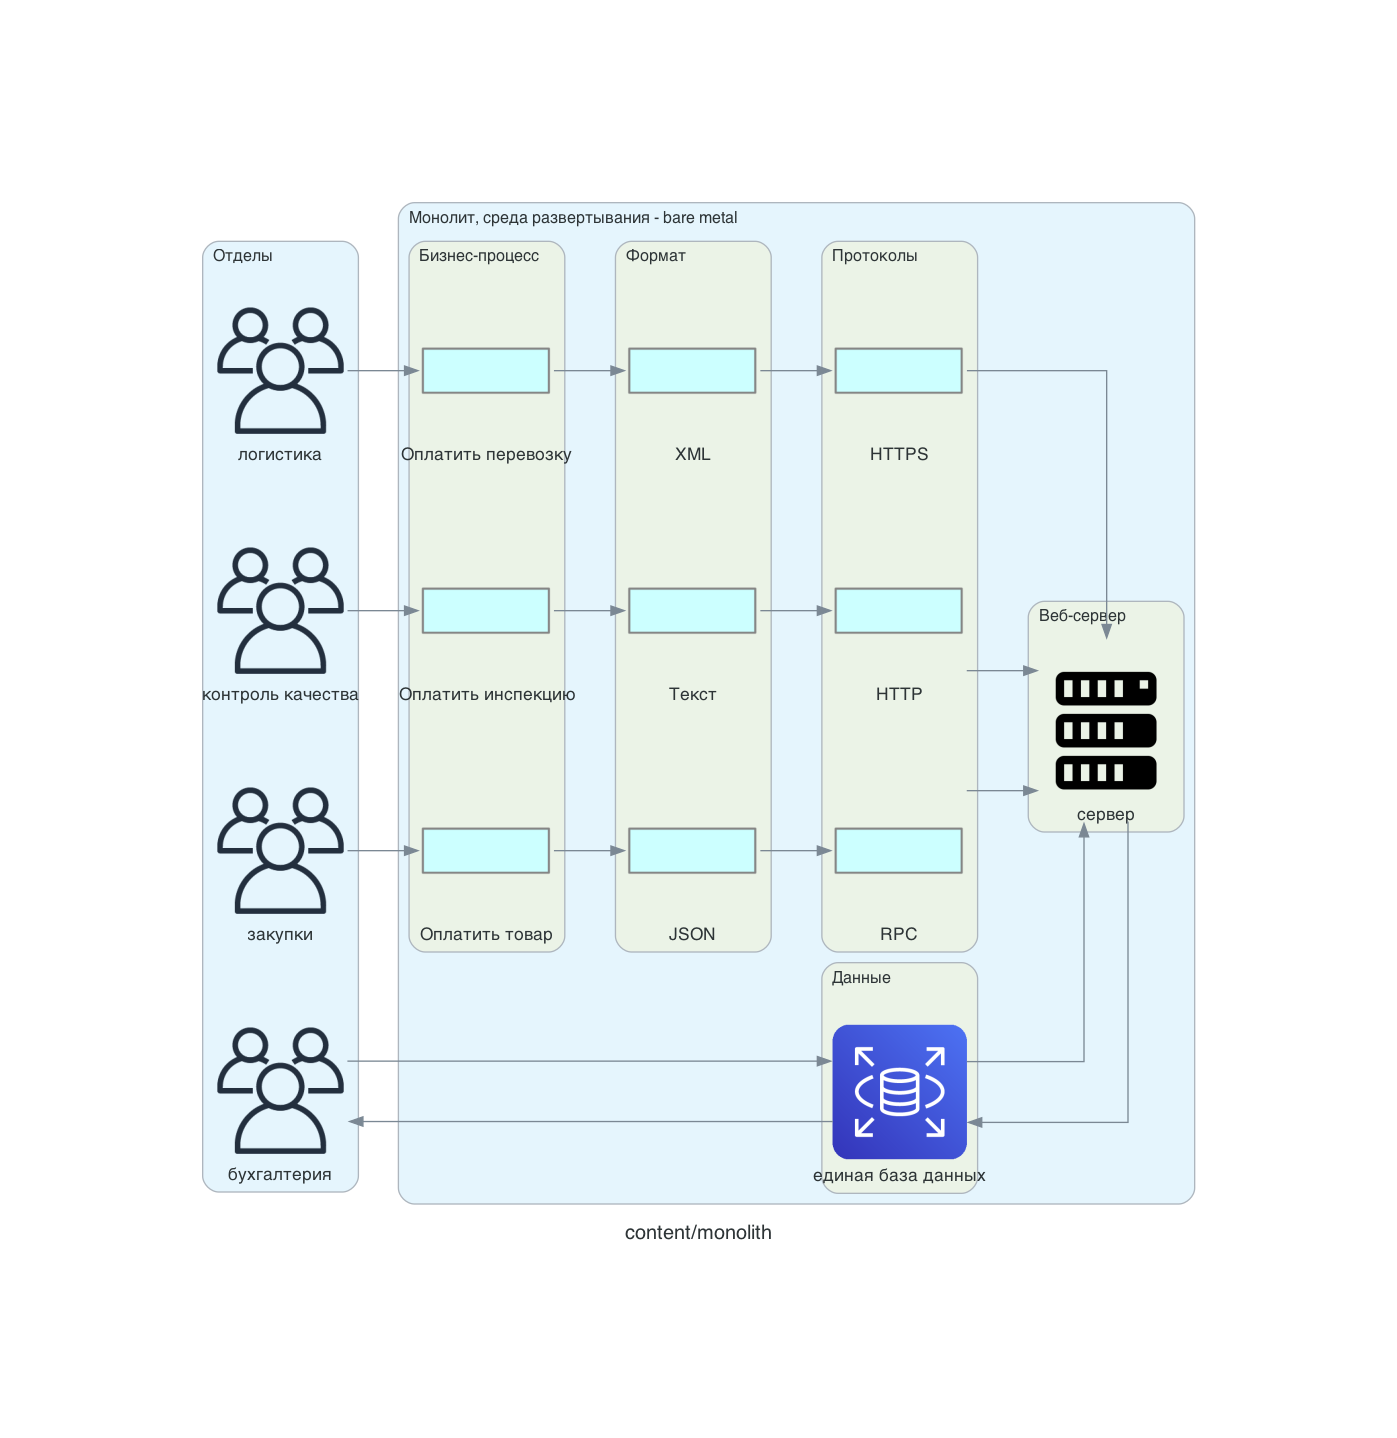

In [35]:
!python content/diagram.py
image_path = './content/monolith.png'
display(Image(filename=image_path))

Задача. Опишите в 5–8 предложениях ваш подход к декомпозиции монолита.

Так как на схеме явно отображен какой-то производственный цикл, где есть закупка, контроль качества, логистика (видимо, это какая-то отгрузка), то разделение на микросервисы мне кажется логичным, так как нам нужна целостность данных, и, возможно, нужна сквозная оценка потерь: сколько мы закупили, сколько ушло, сколько дней прошло, контроль качества, сколько товаров было отгружено. Можем воспользоваться сервис-ориентированной архитектурой.

### SOA

Возьмем сервис-ориентированную архитектуру. Выделим домен каждому отделу. Таким образом, получится четыре сервиса: бухгалтерия, закупки, контроль качества и логистика. База данных остается единая. Сделаем отдельный сервис для бухгалтерии, чтобы она не писала в базу данных напрямую. Организуем обмен данными между сервисами через шину данных.

- Как вы диагностируете связность и выбираете границы сервисов (по доменам, бизнес-процессам или данным, допустим комбинированный вариант).

### DDD

Наш процесс представлен четырьмя отделами, которые взаимодействуют друг с другом и работают с одним и тем же набором данных. Так что выделим четыре домена под каждый из отделов, и они будут общаться между собой через шину данных и обращаться к серверу для выполнения бизнес-логики.

- Какие части вы вынесете первыми, чтобы снять узкое место по RPS, и почему.

Первым делом посмотрим логи запросов, чтобы понять, какой из отделов чаще всего обращается к серверу. Если есть определенный лидер среди этих отделов, то можно начать с него. Если отдела, создающего наибольшую нагрузку, нет, то можно начать с бухгалтерии, так как бухгалтерия — это единственный сервис, который не только отправляет данные на сервер, но и забирает данные с него; также бухгалтерия пишет напрямую в базу данных, что не является хорошей практикой, и заодно с разделением монолита можно также провести рефакторинг работы бухгалтерии.

- Как будете обеспечивать временную совместную работу старого и нового (этапный переход, strangler pattern).

Если мы выбираем сервис-ориентированную архитектуру с использованием шины данных, то мы можем развернуть шину и подключать сервисы к ней по очереди. При добавлении нового веб-сервера, который связан с шиной данных, мы не будем переводить старые сервисы на новую логику, а переводим только один. Таким образом, старые сервисы работают по-старому, новые сервисы работают через шину данных, база данных остается общей.

- Кто владеет данными после разделения и как вы минимизируете риски согласованности.

Для сервис-ориентированной архитектуры мы оставляем единую базу данных, и разделения данных на разные базы не будет. Но риски несогласованности данных все равно остаются, также остаются риски взаимных блокировок. В нашем случае эти риски мы можем решать с помощью возможностей и архитектуры базы данных.

- Нужен ли API-Gateway на входе и какие задачи он возьмет (маршрутизация, аутентификация, агрегация).

При использовании сервис-ориентированной архитектуры нам нужен будет брокер сообщений; в нашем случае это, видимо, RabbitMQ, потому что на схеме мы видим как pull-, так и push-операции.


### Задание 3. Составить документацию взаимодействия сервисов, используя библиотеку docker-compose-diagram

Изучите нотацию библиотеки [Diagrams](https://diagrams.mingrammer.com/docs/nodes/onprem) для указания изображений узлов.

Изучите библиотеку [docker-compose-diagram](https://github.com/skonik/docker-compose-diagram) для документирования докер-компоуз-файлов с помощью лейблов.

Создайте диаграмму простого взаимодействия сервисов (веб-сервер и база данных) добавляя лейблы, чтобы получилось примерно как изображено на рисунке.

%%html

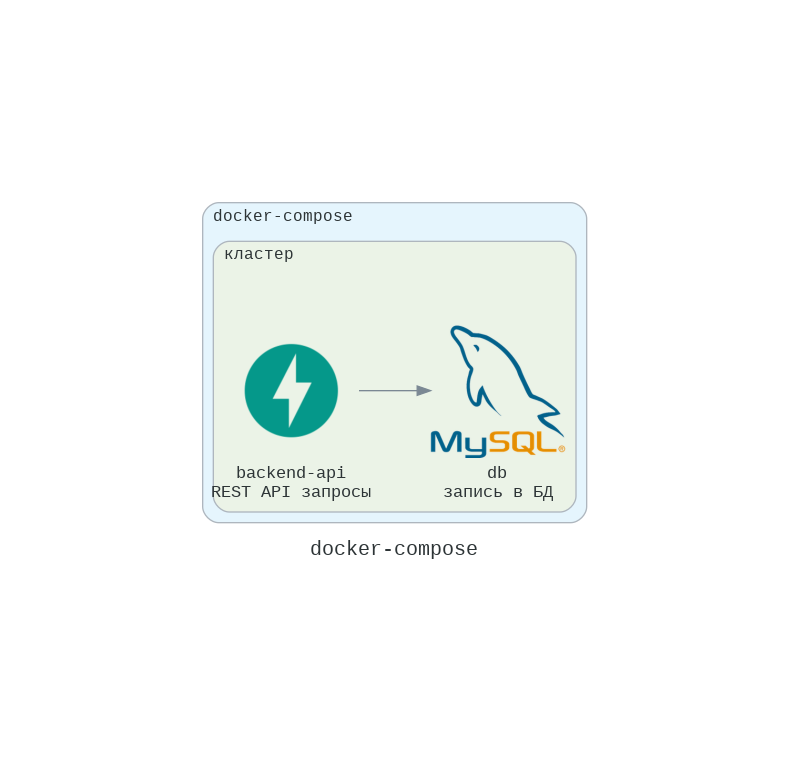

In [36]:
%%writefile docker-compose.yml
services:

  backend-api:
    build:
      context: ..
      dockerfile: docker/django/Dockerfile
    image: dev_backend
    container_name: dev_backend
    restart: always
    volumes:
      - ..:/app/
    depends_on:
      - db
    working_dir: "/app/backend"
    expose:
      - 8000
    ports:
      - "8000:8000"
    command: runserver
    labels:
      "docker_compose_diagram.icon": "diagrams.programming.framework.Django"
      "docker_compose_diagram.cluster": "Кластер"
      "docker_compose_diagram.description": "REST API"

  db:
    container_name: backend_api_db
    image: mysql/mysql-server:8
    volumes:
      - mysql_data:/var/lib/mysql
    restart: unless-stopped
    ports:
      - "3306:3306"
    labels:
      "docker_compose_diagram.icon": "diagrams.onprem.database.Postgresql"
      "docker_compose_diagram.cluster": "Кластер"
      "docker_compose_diagram.description": "База данных\n(CRUD)"

Overwriting docker-compose.yml


In [37]:
!compose-diagram --file docker-compose.yml --direction=LR --nodesep=1.2

File docker-compose.yml has been found. Reading! 📗 
Service: backend-apimWorking..
   Service: {'docker_compose_diagram.icon': 
'diagrams.programming.framework.Django', 'docker_compose_diagram.cluster': 
'Кластер', 'docker_compose_diagram.description': 'REST API'}
Service: dbing..
   Service: {'docker_compose_diagram.icon': 
'diagrams.onprem.database.Postgresql', 'docker_compose_diagram.cluster': 
'Кластер', 'docker_compose_diagram.description': 'База данных\n(CRUD)'}
Your diagram has been saved in docker-compose.png 🖼️
⠹ Working..mWorking..


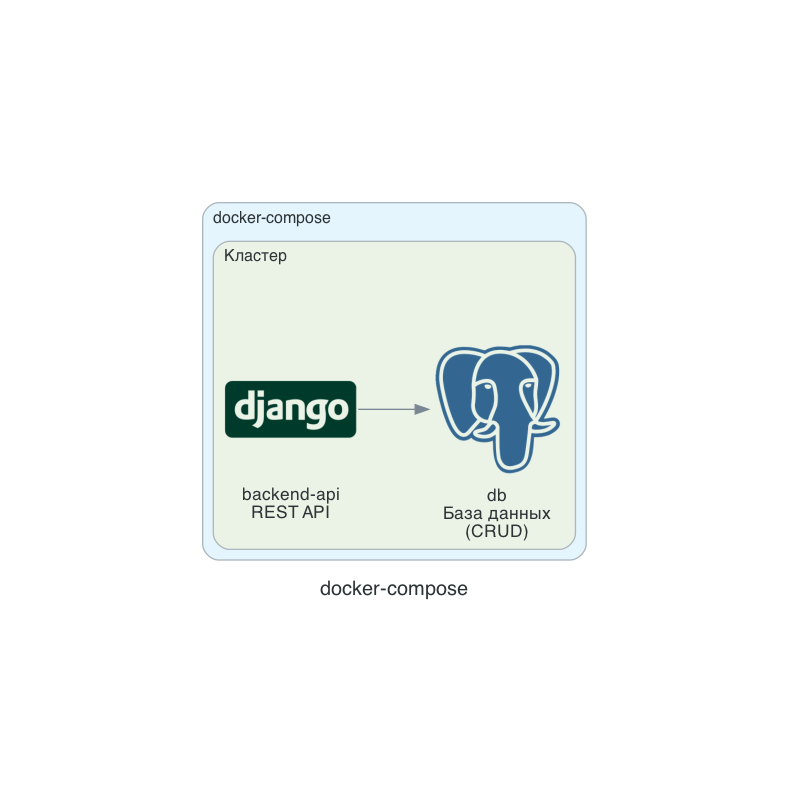

In [38]:
image_path = 'docker-compose.png'
display(Image(filename=image_path))

### Задание 4. Выбрать подходящие паттерны интеграции сервисов (REST/gRPC/брокеры)

Есть монолитное веб-приложение с пропускной способностью ≈200 RPS, при росте нагрузки до ≈400 RPS начинает ощущаться деградация.

Предложите 3 гипотезы, основываясь на [HDD-подходе](https://colab.research.google.com/drive/1vzl2jhLMJuLN-ZcYiPiIeJ7ribHMGDwt?usp=sharing) и исходя из вводных данных:

## REST (будет выдавать 1000 RPS)
* DevCost = 120000 — зарплата разработчиков.
* InfraCost =  50000 — стоимость инфраструктуры.
* featureEstimate = 85 — оценка фичи в стори-поинтах.
* ReworkRate =  0.2; процент доработок/исправлений — от 0.0 до 1.0.

## gRPC (будет выдавать 10000 RPS)

* DevCost = 1000000 — зарплата разработчиков.
* InfraCost =  500000 — стоимость инфраструктуры.
* featureEstimate = 850 — оценка фичи в стори-поинтах.
* ReworkRate =  0.4; процент доработок/исправлений — от 0.0 до 1.0.

## брокеры (будет выдавать 1000000 RPS)

* DevCost = 1200000 — зарплата разработчиков.
* InfraCost =  1500000 — стоимость инфраструктуры.
* featureEstimate = 8500 — оценка фичи в стори-поинтах.
* ReworkRate =  0.6; процент доработок/исправлений — от 0.0 до 1.0.

In [48]:
def calculate_f_python(Cs, g, fe, rf, Sd):
    """Calculates F with error handling for division by zero."""
    try:
        Cs = float(Cs)
        g = float(g)
        fe = float(fe)
        rf = float(rf)
        Sd = float(Sd)

        denominator1 = fe * (1 - rf)
        if denominator1 == 0: return "Ошибка: Деление на ноль (fe * (1 - rf) равно нулю)."

        numerator = Cs + g
        intermediate_result = numerator / denominator1

        if Sd == 0: return "Ошибка: Деление на ноль (Sd равно нулю)."

        F = intermediate_result / Sd
        return f"Стоимость разработки фичи: {F:.2f}"
    except ValueError:
        return "Ошибка: Введены некорректные числовые значения."
    except Exception as e:
        return f"Произошла непредвиденная ошибка: {e}"


In [49]:
params_list = [
    {
        "name": "REST",
        "rps": 1_000,
        "DevCost": 120_000,
        "InfraCost": 50_000,
        "featureEstimate": 85,
        "ReworkRate": 0.2,
    },
    {
        "name": "gRPC",
        "rps": 10_000,
        "DevCost": 1_000_000,
        "InfraCost": 500_000,
        "featureEstimate": 850,
        "ReworkRate": 0.4,
    },
    {
        "name": "brokers",
        "rps": 1_000_000,
        "DevCost": 1_200_000,
        "InfraCost": 1_500_000,
        "featureEstimate": 8_500,
        "ReworkRate": 0.6,
    },
]
for p in params_list:
    result = calculate_f_python(
        p["DevCost"],
        p["InfraCost"],
        p["featureEstimate"],
        p["ReworkRate"],
        0.5, 
    )
    print(f'{p["name"]} ({p["rps"]} RPS): {result}')

REST (1000 RPS): Стоимость разработки фичи: 5000.00
gRPC (10000 RPS): Стоимость разработки фичи: 5882.35
brokers (1000000 RPS): Стоимость разработки фичи: 1588.24


H1: REST
Идея: вынести самые нагруженные части в сервисы с REST, воспользоваться кешированием и горизонтальным масштабированием.


H2: gRPC для внутренних sync-вызовов
Идея: переход внутренних вызовов на gRPC даст снижение нагрузки и запас по RPS.


H3: брокер для асинхронных обменов данными между сервисами
Идея: если нагрузка неравномерная, перевод тяжелых операций в очередь задач через брокер стабилизирует систему

### Задание 5. Разработать схему ML-системы для обработки табличных данных

**Писать код не нужно.**

Нужно составить список вопросов, без которых невозможно начать разработку ML-системы, выбрать архитектуру и составить схематическое описание  ML-системы с помощью библиотеки Diagrams.

**Вводные данные от бизнеса: «Как привлечь клиентов на депозит?» и результат прошлой маркетинговой кампании.**

In [50]:
!pip install scikit-learn -qqq
from sklearn.datasets import fetch_openml
X, y = fetch_openml("bank-marketing", version=1, as_frame=True, return_X_y=True)
display(X.merge(y,left_index=True,right_index=True).tail())
y.value_counts() #<-внес ли клиент срочный депозит по итогам маркетинговой компании? ("да = 2"/"нет = 1")

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,2
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,2
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,2
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,1
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,1


Class
1    39922
2     5289
Name: count, dtype: int64

In [51]:
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown


Список вопросов, без которых невозможно начать разработку ML-системы:
- В датасете не предоставлено описание фичей
- В какой формате предполагается использование модели? Прогноз онлайн или с задержкой?
- Какие были сроки предыдущей маркетинговой кампании?
- Долетят ли дополнительные данные?
- Надо ли дообучать модель в процессе новой кампании?
- Какие сроки выполнения?
- На какую точность модели расчитывает заказчик?

Выбрать архитектуру
- Допустим требования к качеству высокие, сроки позволяют выбрать MSA.

### Схематическое описание  ML-системы с помощью библиотеки Diagrams

In [52]:
from diagrams import Diagram, Cluster
from diagrams.onprem.client import Users
from diagrams.onprem.compute import Server
from diagrams.aws.database import RDS
from diagrams.programming.flowchart import Action

diagram_path = "content/ml_system_deposit_campaign"

with Diagram(diagram_path, show=False, direction="LR"):
    business = Users("Маркетинг /\nCRM")

    with Cluster("Источники данных"):
        campaign_hist = RDS("Результаты\nпрошлой кампании")
        trx_data = RDS("Транзакции")

    with Cluster("Data Platform"):
        etl = Action("Валидация")
        feature_store = RDS("Хранение параметров")
        train_snapshot = RDS("Train/Val")

    with Cluster("ML контур"):
        train = Action("Обучение модели")
        offline_eval = Action("Оценка")
        registry = RDS("Хранение моделей")
        monitor = Action("Мониторинг")
        retrain = Action("Триггер переобучения")

    with Cluster("API"):
        scoring_api = Server("API")

    campaign_hist >> etl
    trx_data >> etl

    etl >> feature_store >> train_snapshot >> train >> offline_eval >> registry

    registry >> scoring_api
    business >> scoring_api

    registry >> monitor >> retrain

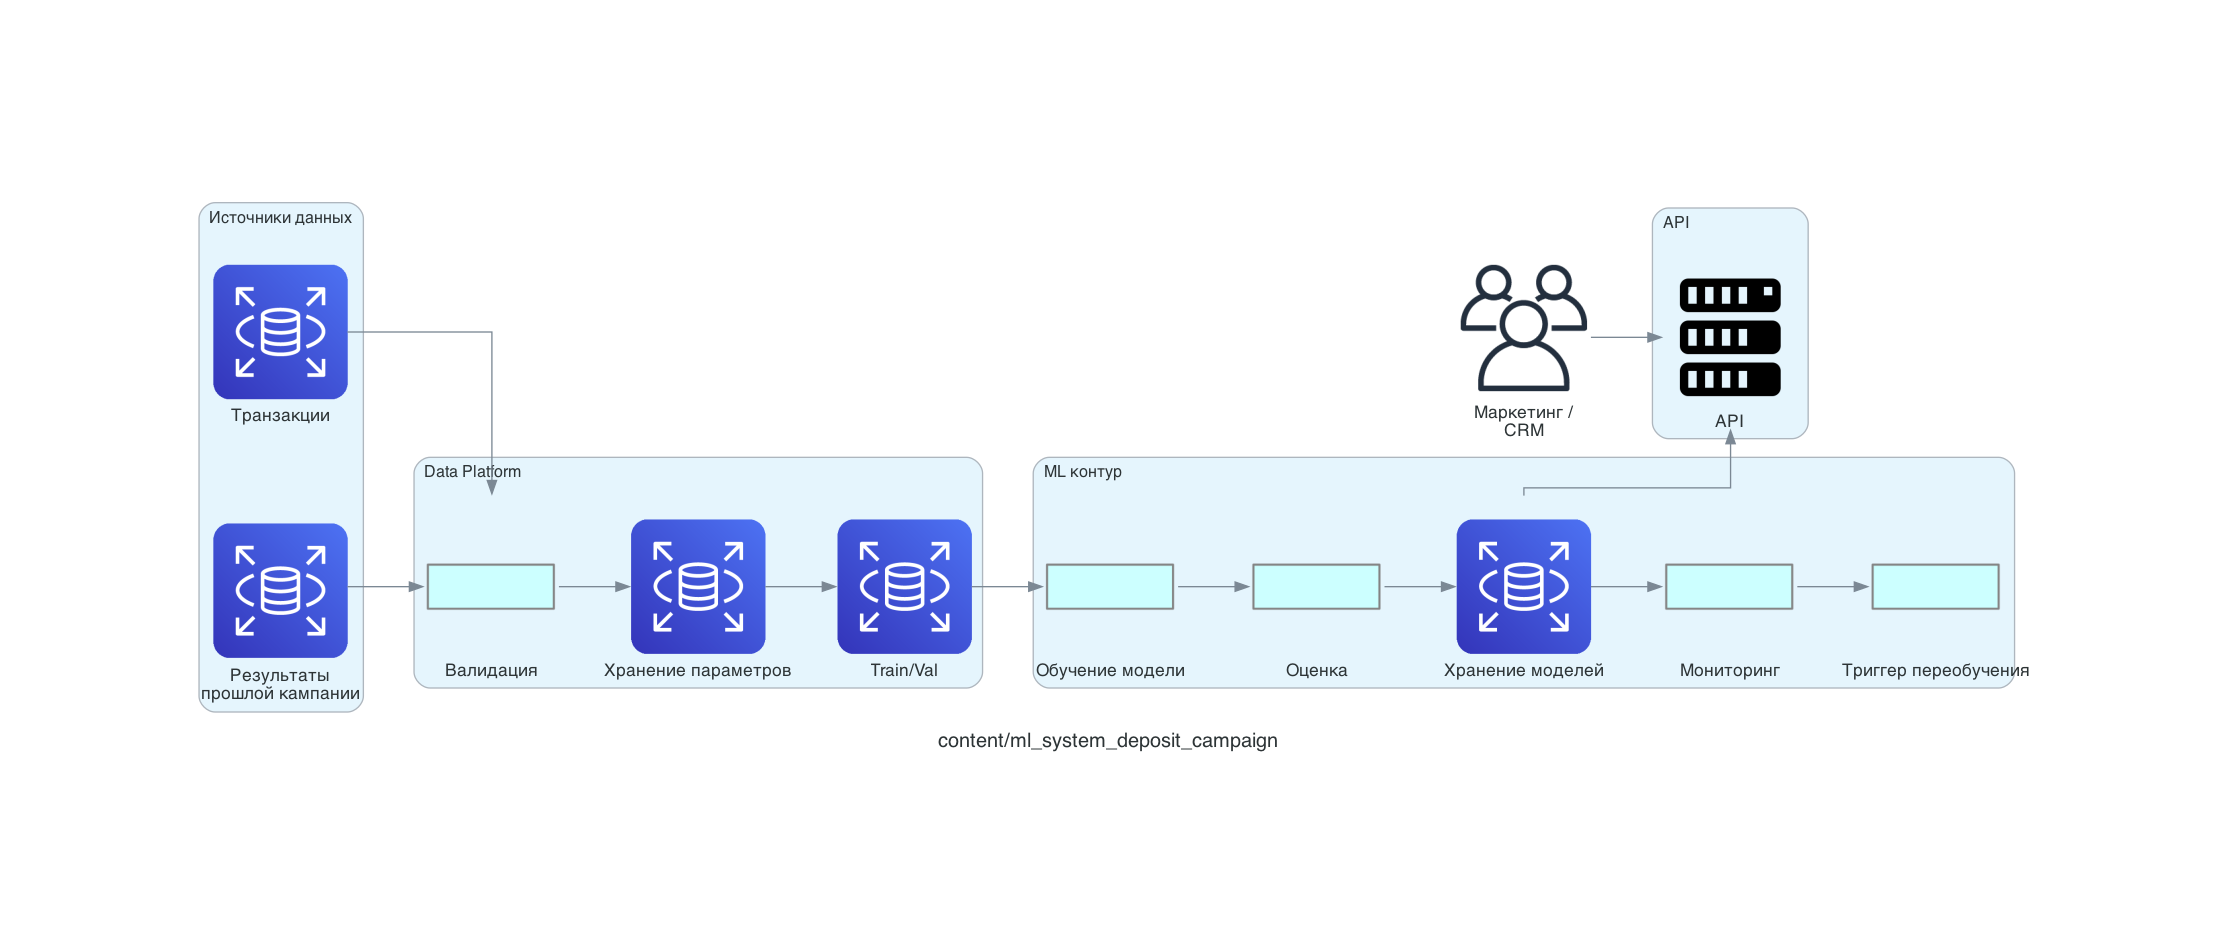

In [53]:
from IPython.display import Image, display

display(Image(filename="content/ml_system_deposit_campaign.png"))

## Итоговое оформление

1. Сформулируйте ниже 5–8 выводов, когда стоит разбивать монолит на микросервисы.
2. Опишите в 5–8 предложениях ваш подход к декомпозиции монолита.
3. Запустите блокнот, чтобы получить диаграмму простого взаимодействия сервисов (веб-сервер и база данных), используя лейблы.
4. Обоснуйте в 5–8 предложениях выбранный паттерн интеграции сервисов.
5. Без чего немыслимо начинать разработку ML-системы?
6. Проверьте, что ноутбук запускается.  